# Part 3 — Molecular Featurization

Now to convert SMILES strings into features for ML models

We compute **three complementary fingerprint types**:

| Feature set | Bits | What it encodes | Used for |
|---|---|---|---|
| ECFP6 (Morgan r=3) | 2048 | Circular substructures around each atom | Main ML features — literature standard |
| MACCS Keys | 167 | Predefined SMARTS substructures | SHAP interpretation (each bit has a name) |
| RDKit 2D descriptors | ~208 | Continuous physicochemical properties | Correlation filtering + ADMET context |

---
## 0. Installs & Imports

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from rdkit import Chem
from rdkit.Chem import AllChem, MACCSkeys, Descriptors, rdMolDescriptors
from sklearn.feature_selection import VarianceThreshold

import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
print('All imports OK')

All imports OK


---
## 1. Load Cleaned Data

In [2]:
df = pd.read_csv('../data/processed/egfr_bioactivity_cleaned.csv')

print(f'Compounds loaded : {len(df):,}')
print(f'Columns          : {list(df.columns)}')
df.head(3)

Compounds loaded : 9,876
Columns          : ['molecule_chembl_id', 'canonical_smiles', 'inchi_key', 'pchembl_value', 'bioactivity_class', 'group_type']


,molecule_chembl_id,canonical_smiles,inchi_key,pchembl_value,bioactivity_class,group_type
0,CHEMBL268868,O=C1NC(=O)c2cc(Nc3ccccc3)c(Nc3ccccc3)cc21,AAALVYBICLMAMA-UHFFFAOYSA-N,6.52,active,single_entry
1,CHEMBL2029442,COc1cc(N2CCN(C)CC2)ccc1Nc1ncc2c(n1)N(c1cccc(N)...,AAFHSECTTHOVFV-UHFFFAOYSA-N,6.32,active,single_entry
2,CHEMBL2048906,CC(=O)NCCn1ccc2ncnc(Nc3ccc(Oc4cccc5sncc45)c(Cl...,AAGKMGNYUYCEPD-UHFFFAOYSA-N,8.54,active,single_entry


In [3]:
# Quick sanity check — no nulls in the two columns we need
assert df['canonical_smiles'].notna().all(), 'Found null SMILES'
assert df['pchembl_value'].notna().all(),    'Found null pChEMBL'
print('Sanity checks passed.')

Sanity checks passed.


---
## 2. RDKit Molecule Objects

All three fingerprint functions need a valid `Mol` object.
We build them once here so we never parse SMILES twice.

In [5]:
from src.features import smiles_to_mol

df['mol'] = df['canonical_smiles'].apply(smiles_to_mol)

n_invalid = df['mol'].isna().sum()
if n_invalid > 0:
    print(f'WARNING: {n_invalid} invalid SMILES — dropping those rows')
    df = df[df['mol'].notna()].copy()
else:
    print(f'All {len(df):,} SMILES parsed successfully.')

All 9,876 SMILES parsed successfully.


---
## 3. Fingerprint 1 — ECFP6 (Morgan, radius=3)

Each bit represents a unique circular substructure around an atom.

**Why ECFP6:**
Vignaux et al. (2023) used ECFP6 as the feature set for their AChE benchmark
(SVR R²=0.81). DeepEGFR (2025) used PubChem + Klekota-Roth fingerprints.
ECFP6 at 2048 bits is the field-wide standard.

In [6]:
from src.features import compute_ecfp6


X_ecfp6_raw = compute_ecfp6(df['mol'])
print(f'ECFP6 raw shape  : {X_ecfp6_raw.shape}')

ECFP6 raw shape  : (9876, 2048)


In [7]:
# ── Variance threshold: remove bits that are almost always 0 or always 1 ──
# For a binary bit with frequency p: variance = p*(1-p)
# threshold=0.05 keeps bits present in roughly 5–95% of compounds
sel_ecfp6 = VarianceThreshold(threshold=0.05)
sel_ecfp6.fit(X_ecfp6_raw)

X_ecfp6 = pd.DataFrame(
    sel_ecfp6.transform(X_ecfp6_raw),
    columns=X_ecfp6_raw.columns[sel_ecfp6.get_support()]
)

print(f'ECFP6 after VarianceThreshold(0.05): {X_ecfp6.shape}')
print(f'  Bits removed: {X_ecfp6_raw.shape[1] - X_ecfp6.shape[1]}')
X_ecfp6.head(2)

ECFP6 after VarianceThreshold(0.05): (9876, 339)
  Bits removed: 1709


,ecfp6_1,ecfp6_13,ecfp6_14,ecfp6_20,ecfp6_31,ecfp6_32,ecfp6_41,ecfp6_43,ecfp6_45,ecfp6_65,...,ecfp6_1962,ecfp6_1970,ecfp6_1984,ecfp6_1991,ecfp6_1993,ecfp6_2004,ecfp6_2009,ecfp6_2013,ecfp6_2017,ecfp6_2021
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,1,0


---
## 4. Fingerprint 2 — MACCS Keys

167 structural keys, each defined by a SMARTS pattern
(e.g., bit 163 = 'aromatic ring present', bit 141 = 'H-bond acceptor').

**Why use it:**
Unlike ECFP6, every MACCS bit has a human-readable chemical meaning.
This makes it the best feature set for **SHAP interpretation** in Part 6:
we´ll try to see what chemical structures influence predections

In [8]:
from src.features import compute_maccs


X_maccs_raw = compute_maccs(df['mol'])
print(f'MACCS raw shape  : {X_maccs_raw.shape}')

MACCS raw shape  : (9876, 167)


In [9]:
# ── Variance threshold (same logic as ECFP6) ─────────────────────────────────
sel_maccs = VarianceThreshold(threshold=0.05)
sel_maccs.fit(X_maccs_raw)

X_maccs = pd.DataFrame(
    sel_maccs.transform(X_maccs_raw),
    columns=X_maccs_raw.columns[sel_maccs.get_support()]
)

print(f'MACCS after VarianceThreshold(0.05): {X_maccs.shape}')
print(f'  Bits removed: {X_maccs_raw.shape[1] - X_maccs.shape[1]}')
X_maccs.head(2)

MACCS after VarianceThreshold(0.05): (9876, 114)
  Bits removed: 53


,maccs_22,maccs_24,maccs_25,maccs_34,maccs_36,maccs_37,maccs_38,maccs_41,maccs_42,maccs_45,...,maccs_150,maccs_151,maccs_152,maccs_153,maccs_154,maccs_155,maccs_157,maccs_159,maccs_160,maccs_164
0,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,1,0,0,1,0,1
1,0,0,1,0,0,1,1,0,0,0,...,1,1,1,1,1,0,1,1,1,1


---
## 5. Fingerprint 3 — RDKit 2D Descriptors

~208 continuous physicochemical properties computed by RDKit like molecular weight, logP, ring counts, charge descriptors, etc.

**Why use it:**
Unlike binary fingerprints, these are continuous values directly tied to
ADMET properties. They are the only feature set where

In [10]:
from src.features import compute_rdkit2d


print('Computing RDKit 2D descriptors... (may take ~1-2 min for large datasets)')
X_rdkit2d_raw = compute_rdkit2d(df['mol'])
print(f'RDKit 2D raw shape: {X_rdkit2d_raw.shape}')

Computing RDKit 2D descriptors... (may take ~1-2 min for large datasets)
RDKit 2D raw shape: (9876, 208)


In [11]:
# ── Step 1: Drop descriptors with any NaN values ─────────────────────────────
n_before = X_rdkit2d_raw.shape[1]
X_rdkit2d_clean = X_rdkit2d_raw.dropna(axis=1)
print(f'After dropping NaN columns: {X_rdkit2d_clean.shape[1]} (removed {n_before - X_rdkit2d_clean.shape[1]})')

# ── Step 2: Drop infinite values ─────────────────────────────────────────────
X_rdkit2d_clean = X_rdkit2d_clean.replace([np.inf, -np.inf], np.nan).dropna(axis=1)
print(f'After dropping Inf columns : {X_rdkit2d_clean.shape[1]}')

After dropping NaN columns: 196 (removed 12)
After dropping Inf columns : 196


In [12]:
# ── Step 3: Pearson correlation filter 
# Remove one of any pair of descriptors with |correlation| > 0.95

corr_matrix = X_rdkit2d_clean.corr().abs()
upper_tri   = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

cols_to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > 0.95)] # The 0.95 is a commun practiice threshold  for correlation in chem
X_rdkit2d = X_rdkit2d_clean.drop(columns=cols_to_drop)

print(f'After correlation filter (>0.95): {X_rdkit2d.shape[1]} descriptors') 
print(f'  Descriptors removed: {len(cols_to_drop)}')
X_rdkit2d.head(2)

After correlation filter (>0.95): 163 descriptors
  Descriptors removed: 33


,MaxEStateIndex,MinEStateIndex,MinAbsEStateIndex,qed,MolWt,NumRadicalElectrons,FpDensityMorgan1,FpDensityMorgan2,BalabanJ,BertzCT,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,11.970074,-0.372803,0.372803,0.631443,329.359,0.0,0.600000,1.000000,1.781739,874.935104,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,13.080495,-0.178833,0.178833,0.543424,474.569,0.0,1.028571,1.828571,1.445660,1241.886509,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


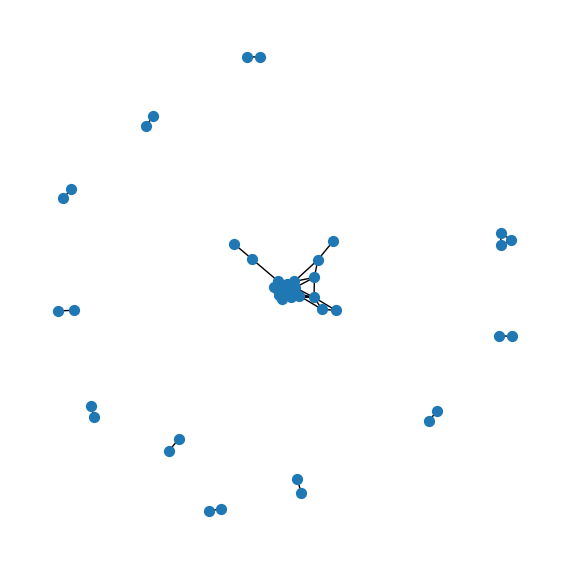

In [13]:
G = nx.Graph()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.95:
            G.add_edge(corr_matrix.columns[i], corr_matrix.columns[j])

plt.figure(figsize=(5.5, 5.5))
nx.draw(G, node_size=50, with_labels=False)
plt.show()

## Correlation AFTER filtering

In [14]:

corr_matrix_filtered = X_rdkit2d.corr(method="spearman").abs()

In [15]:
print("Max correlation remaining:", corr_matrix_filtered.values[np.triu_indices_from(corr_matrix_filtered, k=1)].max())

Max correlation remaining: nan


In [16]:
high_corr_post = (
    corr_matrix_filtered.where(
        np.triu(np.ones(corr_matrix_filtered.shape), k=1).astype(bool)
    )
    .stack()
    .reset_index()
)

high_corr_post.columns = ["Feature_1", "Feature_2", "Correlation"]

# Filtra threshold
high_corr_post = high_corr_post[high_corr_post["Correlation"] > 0.95]
high_corr_post = high_corr_post.sort_values(by="Correlation", ascending=False)

print(high_corr_post.head(20))

    Feature_1 Feature_2  Correlation
604     MolWt       Ipc     0.951164


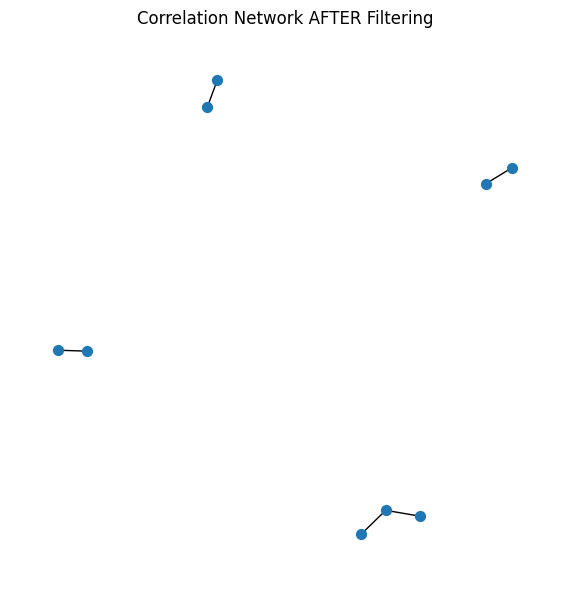

In [17]:
import networkx as nx

G = nx.Graph()

for i in range(len(corr_matrix_filtered.columns)):
    for j in range(i):
        if corr_matrix_filtered.iloc[i, j] > 0.9:
            G.add_edge(corr_matrix_filtered.columns[i], corr_matrix_filtered.columns[j])

plt.figure(figsize=(5.5, 5.5))
nx.draw(G, node_size=50, with_labels=False)
plt.title("Correlation Network AFTER Filtering")
plt.show()

---
## 6. Target Variables (Y)

Two target variables — one for regression, one for classification.

In [18]:
# Regression target: continuous pChEMBL value
y_pchembl = df[['molecule_chembl_id', 'pchembl_value']].reset_index(drop=True)

# Classification target: active / intermediate / inactive
y_class   = df[['molecule_chembl_id', 'bioactivity_class']].reset_index(drop=True)

# Binary classification target (active / inactive only — intermediates excluded)
y_binary  = y_class[y_class['bioactivity_class'] != 'intermediate'].copy()

print(f'y_pchembl shape  : {y_pchembl.shape}')
print(f'y_class shape    : {y_class.shape}  →  {y_class["bioactivity_class"].value_counts().to_dict()}')
print(f'y_binary shape   : {y_binary.shape}')

y_pchembl shape  : (9876, 2)
y_class shape    : (9876, 2)  →  {'active': 7439, 'intermediate': 1722, 'inactive': 715}
y_binary shape   : (8154, 2)


---
## 7. Feature Set Summary

Before saving, confirm all matrices have matching row counts.

In [19]:
summary = pd.DataFrame([
    ('ECFP6 (raw)',           X_ecfp6_raw.shape[0], X_ecfp6_raw.shape[1],  'binary bits'),
    ('ECFP6 (filtered)',      X_ecfp6.shape[0],     X_ecfp6.shape[1],      'binary bits'),
    ('MACCS keys (raw)',      X_maccs_raw.shape[0], X_maccs_raw.shape[1],  'binary bits'),
    ('MACCS keys (filtered)', X_maccs.shape[0],     X_maccs.shape[1],      'binary bits'),
    ('RDKit 2D (raw)',        X_rdkit2d_raw.shape[0],X_rdkit2d_raw.shape[1],'continuous'),
    ('RDKit 2D (filtered)',   X_rdkit2d.shape[0],   X_rdkit2d.shape[1],    'continuous'),
], columns=['Feature set', 'Rows', 'Columns', 'Type'])

print(summary.to_string(index=False))

# All row counts must match
assert X_ecfp6.shape[0] == X_maccs.shape[0] == X_rdkit2d.shape[0] == len(df), \
    'Row count mismatch — check for dropped compounds'
print('\nRow count check passed.')

          Feature set  Rows  Columns        Type
          ECFP6 (raw)  9876     2048 binary bits
     ECFP6 (filtered)  9876      339 binary bits
     MACCS keys (raw)  9876      167 binary bits
MACCS keys (filtered)  9876      114 binary bits
       RDKit 2D (raw)  9876      208  continuous
  RDKit 2D (filtered)  9876      163  continuous

Row count check passed.


---
## 8. Add Molecule ID Index & Save

We add `molecule_chembl_id` as a column (not the index) so that each CSV
is self-contained and can be merged back by ID later.

In [21]:
mol_ids = df['molecule_chembl_id'].reset_index(drop=True)

# Prepend the ID column to each feature matrix
from src.features import add_id

X_ecfp6_out  = add_id(X_ecfp6,  mol_ids)
X_maccs_out  = add_id(X_maccs,  mol_ids)
X_rdkit2d_out= add_id(X_rdkit2d,mol_ids)

# Save all outputs
X_ecfp6_out.to_csv('../data/processed/X_ecfp6.csv',    index=False)
X_maccs_out.to_csv('../data/processed/X_maccs.csv',    index=False)
X_rdkit2d_out.to_csv('../data/processed/X_rdkit2d.csv', index=False)
y_pchembl.to_csv('../data/processed/y_pchembl.csv',    index=False)
y_class.to_csv('../data/processed/y_class.csv',        index=False)
y_binary.to_csv('../data/processed/y_binary.csv',      index=False)

print('Saved:')
print(f'  X_ecfp6.csv   → {X_ecfp6_out.shape}')
print(f'  X_maccs.csv   → {X_maccs_out.shape}')
print(f'  X_rdkit2d.csv → {X_rdkit2d_out.shape}')
print(f'  y_pchembl.csv → {y_pchembl.shape}')
print(f'  y_class.csv   → {y_class.shape}')
print(f'  y_binary.csv  → {y_binary.shape}')

Saved:
  X_ecfp6.csv   → (9876, 340)
  X_maccs.csv   → (9876, 115)
  X_rdkit2d.csv → (9876, 164)
  y_pchembl.csv → (9876, 2)
  y_class.csv   → (9876, 2)
  y_binary.csv  → (8154, 2)


---
## 9. Quick Visual Check


In [22]:
X_ecfp6_out

,molecule_chembl_id,ecfp6_1,ecfp6_13,ecfp6_14,ecfp6_20,ecfp6_31,ecfp6_32,ecfp6_41,ecfp6_43,ecfp6_45,...,ecfp6_1962,ecfp6_1970,ecfp6_1984,ecfp6_1991,ecfp6_1993,ecfp6_2004,ecfp6_2009,ecfp6_2013,ecfp6_2017,ecfp6_2021
0,CHEMBL268868,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,CHEMBL2029442,0,0,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
2,CHEMBL2048906,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,CHEMBL5757238,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,CHEMBL1240554,0,0,0,0,0,0,0,0,0,...,0,1,1,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9871,CHEMBL247710,0,0,0,0,0,1,0,1,0,...,1,1,0,0,0,0,0,0,0,0
9872,CHEMBL2178349,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9873,CHEMBL4570293,0,0,1,0,0,0,0,0,0,...,0,1,0,1,0,0,0,1,0,0
9874,CHEMBL2437476,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0


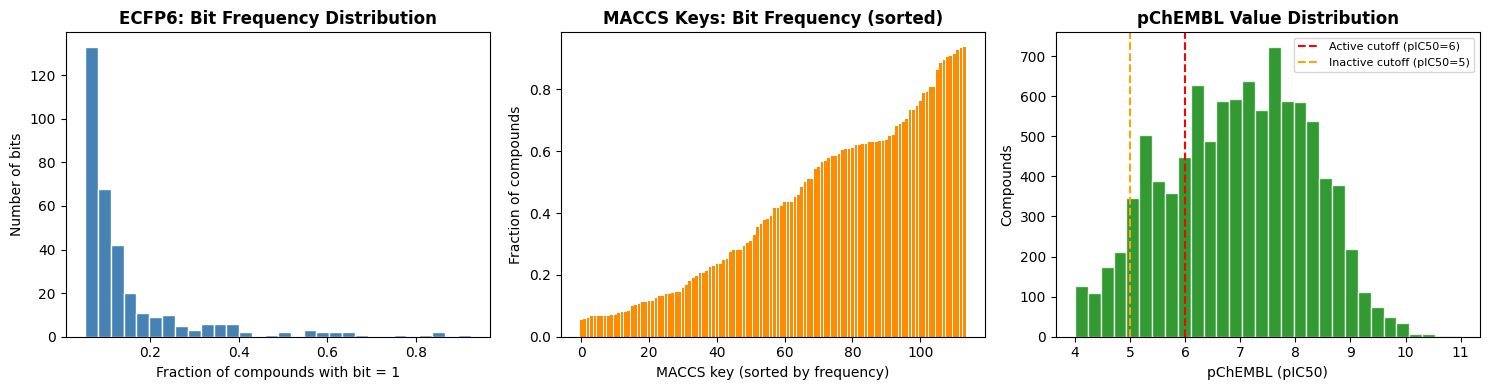

Figure saved as part3_feature_distributions.png


In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ECFP6: bit frequency distribution
bit_freq_ecfp6 = X_ecfp6.mean()
axes[0].hist(bit_freq_ecfp6, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('ECFP6: Bit Frequency Distribution', fontweight='bold')
axes[0].set_xlabel('Fraction of compounds with bit = 1')
axes[0].set_ylabel('Number of bits')

# MACCS: bit frequency distribution
bit_freq_maccs = X_maccs.mean()
axes[1].bar(range(len(bit_freq_maccs)), sorted(bit_freq_maccs), color='darkorange')
axes[1].set_title('MACCS Keys: Bit Frequency (sorted)', fontweight='bold')
axes[1].set_xlabel('MACCS key (sorted by frequency)')
axes[1].set_ylabel('Fraction of compounds')

# pChEMBL distribution
axes[2].hist(y_pchembl['pchembl_value'], bins=30, color='green', edgecolor='white', alpha=0.8)
axes[2].axvline(x=6.0, color='red', linestyle='--', label='Active cutoff (pIC50=6)')
axes[2].axvline(x=5.0, color='orange', linestyle='--', label='Inactive cutoff (pIC50=5)')
axes[2].set_title('pChEMBL Value Distribution', fontweight='bold')
axes[2].set_xlabel('pChEMBL (pIC50)')
axes[2].set_ylabel('Compounds')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../figs/eda/part3_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as part3_feature_distributions.png')

---

**Why VarianceThreshold instead of correlation for ECFP6/MACCS fingerprints?**

Binary bits have variance = p*(1-p). Bits present in very few compounds (e.g., <5%) carry little information — removing them reduces noise.

Pearson correlation between binary bits is sensitive to class imbalance and can be misleading for rare bits. Therefore, correlation filtering is not applied to fingerprints.

Correlation filtering is used only for continuous RDKit 2D descriptors.